# Utility isolates informative augmentation from near-copying

Thin notebook for the two-spirals experiment. The implementation lives in `rankgen_utility_experiment/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rankgen_utility_experiment.experiment import ExperimentConfig, run_experiment, run_many, summarize, plot_spirals, plot_metric_bars, label_metric_columns
from rankgen_utility_experiment.figures import save_paper_pdf, save_results_csv

k = 4
include_noise_model = False

config = ExperimentConfig(
    seed=9,
    train_per_class=70,
    test_per_class=2_000,
    oracle_per_class=3_000,
    generated_per_class=1000,
    generator_latent_components=4,
    smote_neighbors=k,
    smote_lambda=0.5,
    transfer_ab_neighbors=k,
    transfer_bc_neighbors=k,
    transfer_lambda=1.0,
    rf_n_estimators=50,
    rf_max_depth=None,
    rf_min_samples_leaf=4,
    rf_max_features="sqrt",
    rf_max_real_samples=2_000,
    rf_n_jobs=-1,
    turns=2.0,
    noise=0.085,
)
seeds = list(range(7, 12))

In [2]:
data, generated, one_run = run_experiment(
    config,
    include_noise_model=include_noise_model,
)
save_results_csv(one_run, "two_spirals_one_run", index=False)
label_metric_columns(one_run).round(4)

,seed,generator,n_generated,quality ↑,utility ↑,indistinguishability ↑,similarity ↑,baseline_accuracy ↑,generated_only_accuracy ↑,real_augmented_accuracy ↑,generated_augmented_accuracy ↑,real_augmentation_gain ↑,generated_augmentation_gain ↑,fid_to_oracle ↓,precision ↑,recall ↑,distinguishability_accuracy ↓
0,9,SMOTE interpolation,2000,1.0,0.8264,0.2425,0.1901,0.9312,0.9562,0.9615,0.9562,0.0302,0.025,0.0008,0.9905,0.2067,0.8788
1,9,Transferred local differences,2000,1.0,0.9153,0.5825,0.2420,0.9312,0.9568,0.9608,0.9582,0.0295,0.027,0.0003,0.9840,0.8297,0.7088


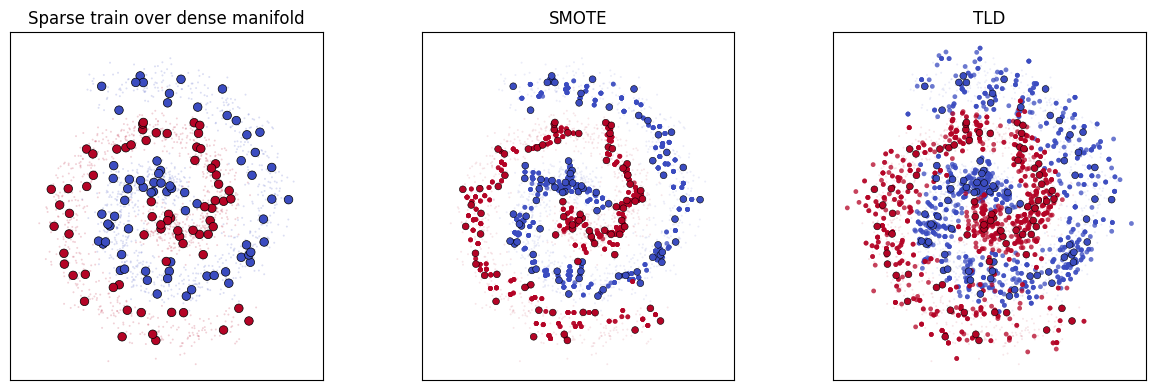

In [3]:
fig = plot_spirals(data, generated)
save_paper_pdf(fig, "two_spirals")
fig;

In [4]:
results = run_many(
    seeds,
    config,
    include_noise_model=include_noise_model,
)
save_results_csv(results, "two_spirals_all_seeds", index=False)
summary = summarize(results)
save_results_csv(summary, "two_spirals_summary")
label_metric_columns(summary).round(4)

quality ↑      utility ↑          \
                                   mean  std      mean     std   
generator                                                        
Transferred local differences       1.0  0.0    0.8555  0.0605   
SMOTE interpolation                 1.0  0.0    0.5621  0.2470   

                              indistinguishability ↑         similarity ↑  \
                                                mean     std         mean   
generator                                                                   
Transferred local differences                 0.5772  0.0152       0.2474   
SMOTE interpolation                           0.2249  0.0107       0.1767   

                                       
                                  std  
generator                              
Transferred local differences  0.0079  
SMOTE interpolation            0.0155

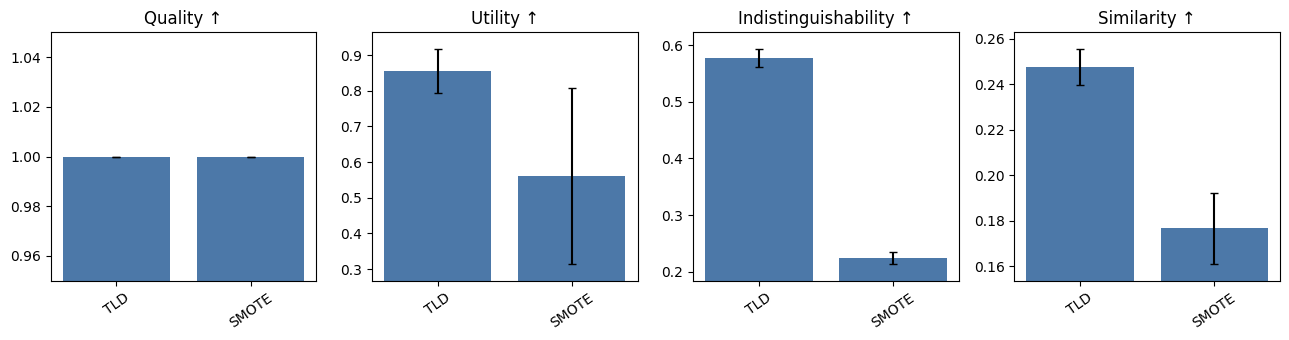

In [5]:
fig = plot_metric_bars(results)
save_paper_pdf(fig, "two_spirals_metrics")
fig;